In [2]:
import os, operator
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel, Field
load_dotenv()

True

In [3]:
model1 = ChatOpenAI(
    model="openai/gpt-oss-120b",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
)

model2 = ChatOpenAI(
    model="llama-3.3-70b-versatile",
    base_url="https://api.groq.com/openai/v1",
    api_key=os.getenv("GROQ_API_KEY"),
    temperature=0,
)

In [4]:
class EvaluationSchema(BaseModel):

    feedback: str = Field(description="Detailed feedback on the essay.")
    score: int = Field(description="Score out of 10.", ge=0, le=10)

In [5]:
structured_model = model1.with_structured_output(EvaluationSchema)

In [24]:
essay = """
    # The Future of AI: From Answering to Acting

## Introduction

For most of its public life, artificial intelligence has been something you *ask*. You typed a question and a model typed back — a search engine with better manners, a writer with infinite patience. That framing shaped how people imagined AI's future: smarter chatbots, better image generators, more fluent assistants. But the trajectory visible in early 2026 points somewhere different. The center of gravity is shifting from systems that answer to systems that *act* — that plan, use tools, coordinate with each other, and carry multi-step work to completion with limited supervision. Understanding where AI is going now means understanding this shift and the forces pulling it forward, along with the frictions that will decide how far and how fast it goes.

## The Defining Trend: The Rise of Agentic AI

The single most important development shaping AI's near future is the move toward *agentic* systems. The distinction matters. A generative model produces content when prompted — text, code, an image. An agent takes actions toward a goal: it breaks a problem into steps, decides which tools to call, executes those calls, checks the results, and adjusts. Industry commentary through 2026 has increasingly described this as the year agentic systems crossed from research demonstrations and pilots into genuine production use.

What made this leap possible was not a single breakthrough but a convergence. Reasoning improved, so models could plan across multiple steps instead of guessing in a single pass. Tool-integration standards such as the Model Context Protocol gave agents a consistent way to reach external systems. Context windows grew large enough to reduce the architectural gymnastics that earlier agents required. And, crucially, early adopters began reporting concrete efficiency gains, which turned curiosity into investment. The result is a new operating model in which software behaves less like a static program and more like a capable, if fallible, digital colleague.

The frontier is already moving beyond single agents toward *multi-agent* arrangements — small coordinated teams of specialized agents. A customer-operations workflow, for instance, might pair a triage agent that interprets an incoming request, a routing agent that classifies it, a resolution agent equipped with domain tools, and a compliance agent that validates the final action before it executes. These arrangements are dynamic: agents sometimes collaborate and sometimes check one another's work. It is a meaningful structural change in how automated systems get built.

## Reasoning as the New Foundation

Underneath the agentic shift sits a deeper one: the elevation of *reasoning* as the core capability that everything else depends on. Earlier models were, at heart, fluent pattern-matchers. The systems now moving to the front behave more like analysts — decomposing problems, weighing evidence, critiquing their own intermediate conclusions, and refining an answer before committing to it. This structured, step-by-step reasoning is exactly what serious work demands, because tasks involving ambiguity, compliance constraints, or long chains of dependent decisions cannot tolerate a confident guess. When an AI system scores a loan, refactors a codebase, or reconciles a financial ledger, the reasoning process is the product.

This is why reasoning-first models are increasingly treated as the cognitive backbone of any credible AI strategy rather than as one feature among many. The competitive frontier has partly moved from "how fluent is the output" to "how sound is the thinking that produced it."

## The Economics of Intelligence

A less glamorous but equally consequential trend is the growing attention to cost. Agentic systems are expensive to run in a way single-shot chatbots never were. Instead of one pass, an agent may reason iteratively, make many tool calls, and accumulate context across a long task — and every additional step consumes tokens and compute. An agent handling thousands of support tickets or code changes a day can become costly quickly without deliberate optimization.

The industry's response is reshaping system architecture. Rather than routing every request to a single expensive frontier model, teams are adopting *tiered* designs: small, task-tuned models handle routing, classification, and simple extraction, while frontier models are reserved for genuinely hard reasoning. A router decides which tier each call deserves. Design patterns reinforce this — a capable model can draft a plan that cheaper models then execute, cutting costs dramatically compared with using top-tier models for everything. The emergence of competitive lower-cost reasoning models has pushed this cost-performance frontier further still. In short, "which model should run this?" is becoming as central an engineering question as "can a model do this at all" — a maturation that echoes how cloud cost optimization became unavoidable in the microservices era.

## Reliability, Evaluation, and Trust

As AI moves from drafting suggestions to taking actions, the tolerance for error drops sharply. A chatbot that occasionally hallucinates is an annoyance; an agent that autonomously executes a wrong action is a liability. This raises the stakes for evaluation and reliability, which are quietly becoming defining concerns of the field.

Testing an agentic system is harder than scoring a benchmark. Organizations increasingly assess not just whether outputs are accurate but whether tasks are actually completed, whether errors propagate through a chain of steps, whether tools are invoked correctly, and whether behavior stays within compliance boundaries. Evaluation is starting to resemble traditional software quality assurance, adapted for systems that are probabilistic rather than deterministic. Teams build simulation environments where agents face structured edge cases before touching anything live, and they monitor continuously afterward, because agent behavior can drift when an underlying model updates or a tool's API changes. Reliability, in other words, is no longer a finishing touch. It is becoming the foundation that determines whether these systems can be deployed at scale at all.

## What This Means for People and Work

The human implications follow directly from the technical ones. The question inside most organizations has shifted from "should we use AI?" to a more textured set: which parts of our work should AI handle, which must remain human, and where do we place checkpoints? That reframing is healthier than the hype-versus-fear binary that preceded it.

Software development offers a preview. The emerging pattern is not the disappearance of developers but a shift from writing code directly to *orchestrating* agents that write code. Engineers who master that orchestration take on broader scope and ship faster; junior contributors can do meaningful work earlier. Yet architectural judgment, strategic direction, and accountability for outcomes remain stubbornly human. This is likely the template for many knowledge-work fields: AI absorbs the mechanical middle of a task while people concentrate on framing the problem at the start and judging the result at the end. The winners will not be those who resist the tools or those who surrender everything to them, but those who redesign their workflows around a realistic division of labor.

## The Frictions Ahead

None of this is guaranteed to unfold smoothly, and an honest analysis has to name the resistance. Cost may constrain ambition — continuously running agents can strain budgets, and not every promised efficiency gain will survive contact with reality. Reliability remains genuinely unsolved; error propagation through multi-step chains is a hard problem, and a single bad step can invalidate an entire workflow. Governance and regulation are still maturing, with frameworks for trust, risk, and security management being assembled while the technology moves underneath them. And there is the persistent risk of over-automation — handing an agent authority it has not earned and discovering the gap only after something breaks. The organizations that do well will be the ones that treat these frictions as design constraints to engineer around rather than inconveniences to wish away.

## Conclusion

The future of AI, read from the trends now visible, is less about a sudden arrival of machine consciousness and more about a steady, consequential change in what software *is*. Systems are learning to reason before they act, to coordinate in teams, to be metered for cost like any other utility, and to be tested for reliability like any other critical infrastructure. The shift from answering to acting is the throughline connecting all of it. If the past decade of AI was about making machines that could talk convincingly, the coming one is about making machines that can be trusted to *do* — carefully, economically, and under human judgment. That is a more modest vision than science fiction promised, but a more useful one, and getting it right is the real work ahead.
"""

In [7]:
prompt = f"""
Evaluate the language, structure, and content of the following essay. Provide detailed feedback and a score out of 10. \n {essay} """

In [8]:
structured_model.invoke(prompt)

EvaluationSchema(feedback='The essay is written in clear, straightforward language and is easy to understand. It uses appropriate vocabulary for a general audience, though it occasionally repeats ideas and could benefit from more varied sentence structures. The structure follows a logical order: an introduction that states the date and significance, a body that mentions freedom fighters and the way the day is celebrated, and a conclusion that reflects on the meaning of the day. Paragraph breaks are present, but transitions between paragraphs are weak and the essay would be stronger with clearer linking sentences. Content-wise, the essay accurately mentions the key facts about India’s Independence Day, the flag‑hoisting ceremony at the Red Fort, and the role of schools. However, it remains fairly superficial; it could be enriched with more historical context, specific examples of celebrations, or a brief discussion of the challenges faced during the independence movement. Overall, the e

In [9]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [12]:
def evaluate_language(state: UPSCState):

    prompt = f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}


In [13]:
def evaluate_analysis(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [15]:
def evaluate_thought(state: UPSCState):

    prompt = f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {state["essay"]}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}



In [22]:
def final_evaluation(state: UPSCState):

    # summary feedback
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback - {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback = model1.invoke(prompt).content

    # avg calculate
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])

    return {'overall_feedback': overall_feedback, 'avg_score': avg_score}

In [18]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)

# edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')

graph.add_edge('final_evaluation', END)

workflow = graph.compile()

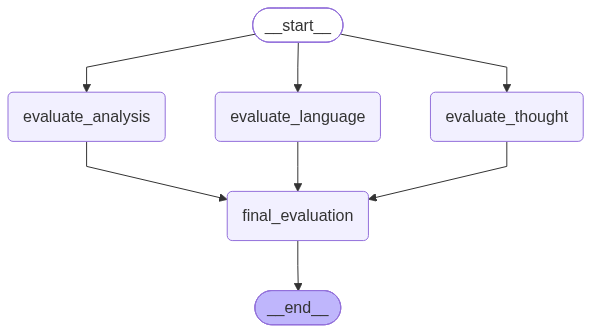

In [19]:
workflow

In [25]:
workflow.invoke({'essay': essay})

{'essay': '\n    # The Future of AI: From Answering to Acting\n\n## Introduction\n\nFor most of its public life, artificial intelligence has been something you *ask*. You typed a question and a model typed back — a search engine with better manners, a writer with infinite patience. That framing shaped how people imagined AI\'s future: smarter chatbots, better image generators, more fluent assistants. But the trajectory visible in early 2026 points somewhere different. The center of gravity is shifting from systems that answer to systems that *act* — that plan, use tools, coordinate with each other, and carry multi-step work to completion with limited supervision. Understanding where AI is going now means understanding this shift and the forces pulling it forward, along with the frictions that will decide how far and how fast it goes.\n\n## The Defining Trend: The Rise of Agentic AI\n\nThe single most important development shaping AI\'s near future is the move toward *agentic* systems. 